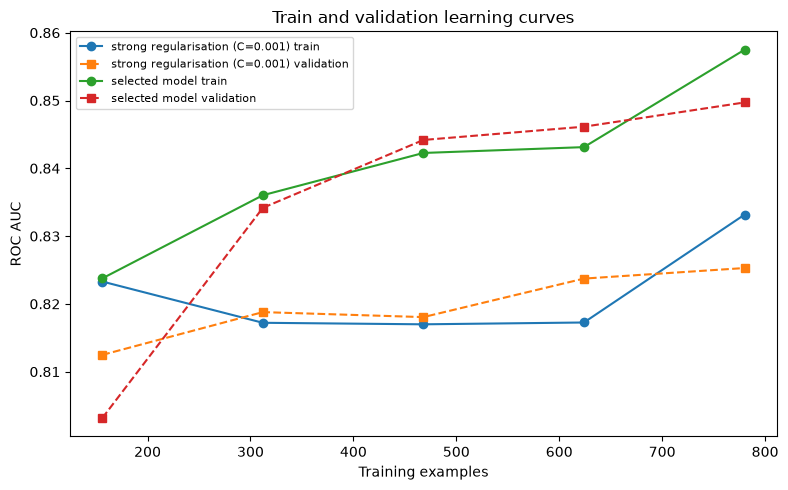

Search comparison:
             search  best_cv_auc  train_auc                                                                                                                          best_params
      GridSearchCV     0.849716   0.857489                            {'logisticregression__C': 0.1, 'logisticregression__l1_ratio': 1.0, 'logisticregression__solver': 'saga'}
RandomizedSearchCV     0.847654   0.859729 {'logisticregression__C': np.float64(3.4702669886504163), 'logisticregression__l1_ratio': 1.0, 'logisticregression__solver': 'saga'}
Selected model: {
  "selected_search": "GridSearchCV",
  "best_params": {
    "logisticregression__C": 0.1,
    "logisticregression__l1_ratio": 1.0,
    "logisticregression__solver": "saga"
  },
  "best_cv_auc": 0.8497159688617714,
  "holdout_auc": 0.8605241233053094,
  "grid_train_validation_gap": 0.007773469232544961
}
Self-review: stratified CV used, both searches compared, untouched holdout scored, learning curves saved.
Evidence: C:\cynarisis-

In [1]:
# W4D2: Bias?Variance Tradeoff & Regularisation
# One reproducible workflow: compare train/validation scores, grid/random search, and learning curves.
from pathlib import Path
import json
import numpy as np
import pandas as pd
try:
    import mlflow
except ImportError:
    mlflow = None
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import loguniform
import matplotlib.pyplot as plt

SEED = 42
OUT = Path("../outputs/w4d2_regularisation")
OUT.mkdir(parents=True, exist_ok=True)
X, y = make_classification(n_samples=1300, n_features=18, n_informative=7,
                           n_redundant=5, class_sep=0.85, flip_y=0.04, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2500, random_state=SEED))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# C controls inverse regularisation strength; compare L1 and L2 penalties.
grid = GridSearchCV(pipe, {"logisticregression__C": [0.01, 0.1, 1, 10],
                           "logisticregression__l1_ratio": [0.0, 1.0],
                           "logisticregression__solver": ["saga"]},
                    scoring="roc_auc", cv=cv, return_train_score=True, n_jobs=1)
grid.fit(X_train, y_train)
# Randomized search samples a wider logarithmic C range with a fixed seed.
random_search = RandomizedSearchCV(pipe, {"logisticregression__C": loguniform(1e-3, 1e2),
                                          "logisticregression__l1_ratio": [0.0, 1.0],
                                          "logisticregression__solver": ["saga"]},
                                   n_iter=16, scoring="roc_auc", cv=cv, return_train_score=True,
                                   random_state=SEED, n_jobs=1)
random_search.fit(X_train, y_train)
# Keep the stronger CV candidate and score it once on the untouched test split.
best = max((grid, random_search), key=lambda search: search.best_score_)
test_auc = roc_auc_score(y_test, best.predict_proba(X_test)[:, 1])
cv_results = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")
cv_results.to_csv(OUT / "grid_search_results.csv", index=False)
comparison = pd.DataFrame([
    {"search": "GridSearchCV", "best_cv_auc": grid.best_score_, "train_auc": grid.cv_results_["mean_train_score"][grid.best_index_], "best_params": str(grid.best_params_)},
    {"search": "RandomizedSearchCV", "best_cv_auc": random_search.best_score_, "train_auc": random_search.cv_results_["mean_train_score"][random_search.best_index_], "best_params": str(random_search.best_params_)}])
comparison.to_csv(OUT / "search_comparison.csv", index=False)
# Compare a deliberately simple model and a flexible model for underfit/overfit signals.
curve_models = {"strong regularisation (C=0.001)": make_pipeline(StandardScaler(), LogisticRegression(C=0.001, max_iter=2500, random_state=SEED)),
                "selected model": best.best_estimator_}
fig, ax = plt.subplots(figsize=(8, 5))
curve_records = []
for label, estimator in curve_models.items():
    curve_result = learning_curve(estimator, X_train, y_train, cv=cv, scoring="roc_auc",
                                  train_sizes=np.linspace(.2, 1, 5), n_jobs=1)
    sizes, train, valid = curve_result[0], curve_result[1], curve_result[2]
    ax.plot(sizes, train.mean(axis=1), marker="o", label=f"{label} train")
    ax.plot(sizes, valid.mean(axis=1), marker="s", linestyle="--", label=f"{label} validation")
    for n, tr, va in zip(sizes, train.mean(axis=1), valid.mean(axis=1)):
        curve_records.append({"model": label, "train_size": int(n), "train_auc": float(tr), "validation_auc": float(va)})
pd.DataFrame(curve_records).to_csv(OUT / "learning_curves.csv", index=False)
ax.set(xlabel="Training examples", ylabel="ROC AUC", title="Train and validation learning curves"); ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(OUT / "learning_curves.png", dpi=140); plt.show()
result = {"selected_search": "GridSearchCV" if best is grid else "RandomizedSearchCV",
          "best_params": best.best_params_, "best_cv_auc": float(best.best_score_),
          "holdout_auc": float(test_auc), "grid_train_validation_gap": float(grid.cv_results_["mean_train_score"][grid.best_index_] - grid.best_score_)}
(OUT / "summary.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
if mlflow is not None:
    mlflow.set_tracking_uri(f"sqlite:///{(OUT / 'mlflow.db').resolve().as_posix()}")
    mlflow.set_experiment("w4d2-regularisation-search")
    with mlflow.start_run(run_name=result["selected_search"]):
        mlflow.log_params({k: str(v) for k, v in best.best_params_.items()})
        mlflow.log_metrics({"best_cv_auc": float(best.best_score_), "holdout_auc": float(test_auc), "train_validation_gap": result["grid_train_validation_gap"]})
        mlflow.log_artifact(str(OUT / "summary.json"))
else:
    (OUT / "mlflow_metrics_fallback.json").write_text(json.dumps({"best_cv_auc": float(best.best_score_), "holdout_auc": float(test_auc), "train_validation_gap": result["grid_train_validation_gap"]}, indent=2), encoding="utf-8")
print("Search comparison:\n", comparison.to_string(index=False))
print("Selected model:", json.dumps(result, indent=2))
print("Self-review: stratified CV used, both searches compared, untouched holdout scored, learning curves saved.")
print("Evidence:", OUT.resolve())
